In [6]:
from typing_extensions import TypedDict
from typing import Literal
import random

class Player(TypedDict):
    name: str
    game: Literal['cicket','badminton']

In [11]:
def play_game(player: Player):
    print("--play game node has been called--")
    return {"name": player["name"]+ " wants to play "}

def cricket(player: Player):
    print("--cricket node has been called--")
    return {"name": player["name"]+ " cricket", "game": "cricket"}

def badminton(player: Player):
    print("--badminton node has been called--")
    return {"name": player["name"]+ " badminton", "game": "badminton"}

def random_play(player: Player)-> Literal['play_cricket','play_badminton']:
    if random.random()>0.5:
        return 'play_cricket'
    else:
        return 'play_badminton'

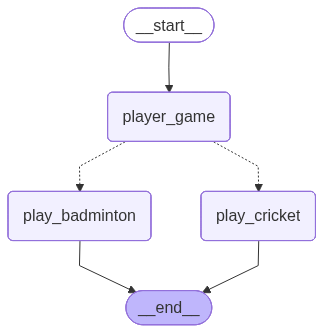

In [12]:
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display
import random

builder = StateGraph(Player)
builder.add_node("player_game", play_game)
builder.add_node("play_cricket", cricket)
builder.add_node("play_badminton", badminton)

builder.add_edge(START, "player_game")
builder.add_conditional_edges("player_game",random_play)
builder.add_edge("play_cricket", END)
builder.add_edge("play_badminton", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
graph.invoke({"name": "Vinay"})

--play game node has been called--
--badminton node has been called--


{'name': 'Vinay wants to play  badminton', 'game': 'badminton'}

In [14]:
from dataclasses import dataclass

@dataclass
class PlayerDataClass:
    name: str
    game: Literal['cicket','badminton'] 

In [15]:
def play_game(player: PlayerDataClass):
    print("--play game node has been called--")
    return {"name": player.name+ " wants to play "}

def cricket(player: PlayerDataClass):
    print("--cricket node has been called--")
    return {"name": player.name+ " cricket", "game": "cricket"}

def badminton(player: PlayerDataClass):
    print("--badminton node has been called--")
    return {"name": player.name+ " badminton", "game": "badminton"}

def random_play(player: PlayerDataClass)-> Literal['play_cricket','play_badminton']:
    if random.random()>0.5:
        return 'play_cricket'
    else:
        return 'play_badminton'

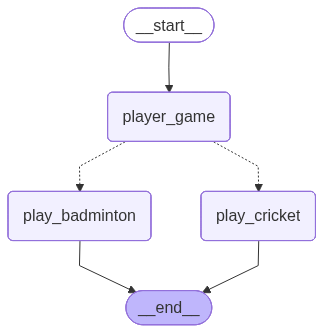

In [16]:
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display
import random

builder = StateGraph(PlayerDataClass)
builder.add_node("player_game", play_game)
builder.add_node("play_cricket", cricket)
builder.add_node("play_badminton", badminton)

builder.add_edge(START, "player_game")
builder.add_conditional_edges("player_game",random_play)
builder.add_edge("play_cricket", END)
builder.add_edge("play_badminton", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
graph.invoke(PlayerDataClass(name="Vinay", game="cricket"))

--play game node has been called--
--badminton node has been called--


{'name': 'Vinay wants to play  badminton', 'game': 'badminton'}